In [1]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
import umap
import hdbscan
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("../Src")
from Src.config import CLEANED_DATA,ANALYZED_DATA
from Src.stopwords_id import get_stopwords

df=pd.read_csv(ANALYZED_DATA)
indonesian_stopwords=list(get_stopwords())

In [2]:
docs = df[df['clean_text'].notna() &
          (df['clean_text'].str.split().str.len() >= 5)]['clean_text'].tolist()

doc_indices = df[df['clean_text'].notna() &
                 (df['clean_text'].str.split().str.len() >= 5)].index.tolist()

print(f"Total dokumen untuk topic modeling: {len(docs)}")

Total dokumen untuk topic modeling: 11222


In [3]:
# Vectorizer
vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.85,
    stop_words=list(indonesian_stopwords)
)

# UMAP
umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

# HDBSCAN
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# BERTopic
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    nr_topics='auto',
    verbose=True
)

topics, probs = topic_model.fit_transform(docs)

print(f"\nJumlah topik ditemukan: {topic_model.nr_topics}")
print(topic_model.get_topic_info().head(15))

2026-05-15 16:31:52,235 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/351 [00:00<?, ?it/s]

2026-05-15 16:32:07,448 - BERTopic - Embedding - Completed ✓
2026-05-15 16:32:07,449 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-15 16:32:23,705 - BERTopic - Dimensionality - Completed ✓
2026-05-15 16:32:23,709 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-15 16:32:24,029 - BERTopic - Cluster - Completed ✓
2026-05-15 16:32:24,029 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-15 16:32:24,229 - BERTopic - Representation - Completed ✓
2026-05-15 16:32:24,230 - BERTopic - Topic reduction - Reducing number of topics
2026-05-15 16:32:24,241 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-15 16:32:24,382 - BERTopic - Representation - Completed ✓
2026-05-15 16:32:24,384 - BERTopic - Topic reduction - Reduced number of topics from 46 to 13



Jumlah topik ditemukan: auto
    Topic  Count                                      Name  \
0      -1   4293                 -1_kan_kasih_lihat_terima   
1       0   5108            0_generasi_enggak_ekonomi_guru   
2       1    401               1_food_vendor_produk_pangan   
3       2    332                 2_menu_basi_susu_serangga   
4       3    300     3_cegah_indonesia emas_gizi anak_atas   
5       4    197         4_papua_anakanak_tolak_anak papua   
6       5    137          5_viral_konten_klarifikasi_media   
7       6    121                   6_gas_gasnow_oke_selalu   
8       7     80          7_banding_daerah_lebih baik_ribu   
9       8     78                 8_buzzer_bayar_tweet_bela   
10      9     69          9_target_juta_juta terima_terima   
11     10     54        10_nutrisi_tumbuh_anakanak_kembang   
12     11     52  11_optimal_tumbuh_tumbuh kembang_kembang   

                                       Representation  \
0   [kan, kasih, lihat, terima, dulu, tahun,

In [4]:
# Mapping topic ke df
topic_series = pd.Series(topics, index=doc_indices)
df['topic_id'] = topic_series
df['topic_id'] = df['topic_id'].fillna(-1).astype(int)

topic_info = topic_model.get_topic_info()
topic_labels = {}
for _, row in topic_info.iterrows():
    tid = row['Topic']
    if tid == -1:
        topic_labels[tid] = 'outlier'
    else:
        top_words = [w for w, _ in topic_model.get_topic(tid)[:3]]
        topic_labels[tid] = '_'.join(top_words)

df['topic_label'] = df['topic_id'].map(topic_labels)

print("Distribusi topik:")
print(df['topic_label'].value_counts().head(15))

Distribusi topik:
topic_label
outlier                           8071
generasi_enggak_ekonomi           5108
food_vendor_produk                 401
menu_basi_susu                     332
cegah_indonesia emas_gizi anak     300
papua_anakanak_tolak               197
viral_konten_klarifikasi           137
gas_gasnow_oke                     121
banding_daerah_lebih baik           80
buzzer_bayar_tweet                  78
target_juta_juta terima             69
nutrisi_tumbuh_anakanak             54
optimal_tumbuh_tumbuh kembang       52
Name: count, dtype: int64


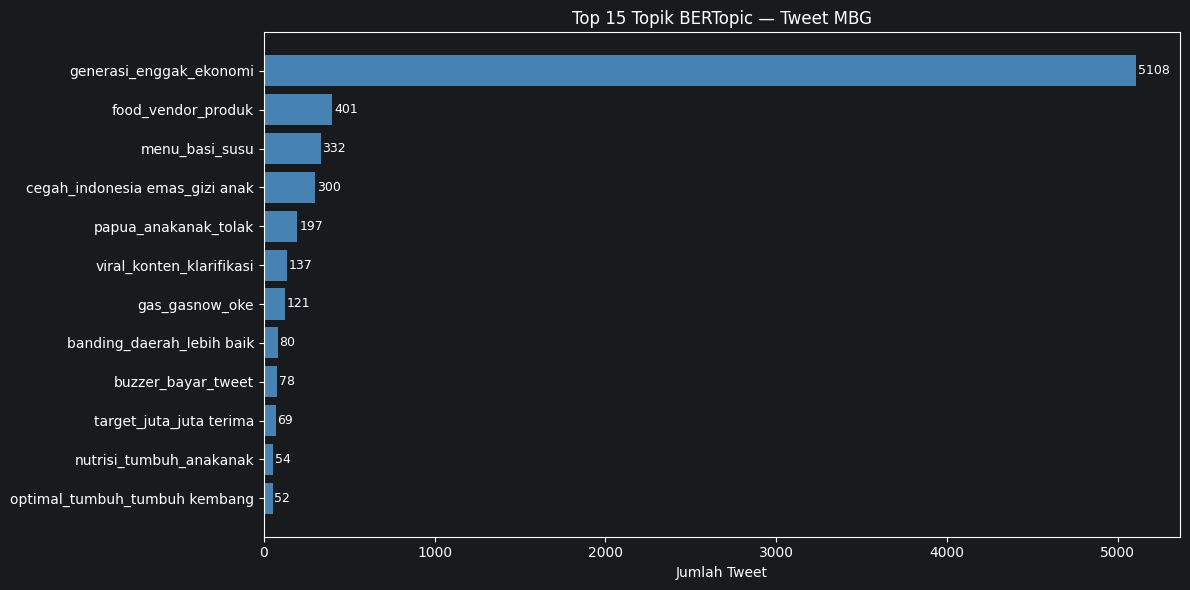


Validasi Topic (BERTopic) × Frame (Manual):
frame_utama                     agama_budaya  anggaran_fiskal  buzzer_hype  \
topic_label                                                                  
banding_daerah_lebih baik                  0               12            0   
buzzer_bayar_tweet                         0               15           32   
cegah_indonesia emas_gizi anak             0                6            1   
food_vendor_produk                         2               31            0   
gas_gasnow_oke                             0               14            0   
generasi_enggak_ekonomi                    7              589           10   
menu_basi_susu                             1               18            0   
nutrisi_tumbuh_anakanak                    0                1            0   
optimal_tumbuh_tumbuh kembang              0                5            0   
papua_anakanak_tolak                       0                7            1   
target_juta_juta te

In [5]:
# Top 15 topik by jumlah tweet
topic_counts = df[df['topic_id'] != -1]['topic_label'].value_counts().head(15)

plt.figure(figsize=(12, 6))
bars = plt.barh(topic_counts.index[::-1], topic_counts.values[::-1], color='steelblue')
plt.title('Top 15 Topik BERTopic — Tweet MBG')
plt.xlabel('Jumlah Tweet')
for bar, val in zip(bars, topic_counts.values[::-1]):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()

# Validasi: crosstab topic vs frame manual
# Ini kunci — kalau topik BERTopic konsisten sama frame kita, narasi makin kuat
validation = pd.crosstab(
    df[df['topic_id'] != -1]['topic_label'],
    df[df['topic_id'] != -1]['frame_utama']
)
print("\nValidasi Topic (BERTopic) × Frame (Manual):")
print(validation)

# Bonus: sentiment per topik
topic_sentiment = df[df['topic_id'] != -1].groupby('topic_label')['sentiment_bert'].value_counts(normalize=True).mul(100).round(1)
print("\nSentimen per Topik (%):")
print(topic_sentiment)

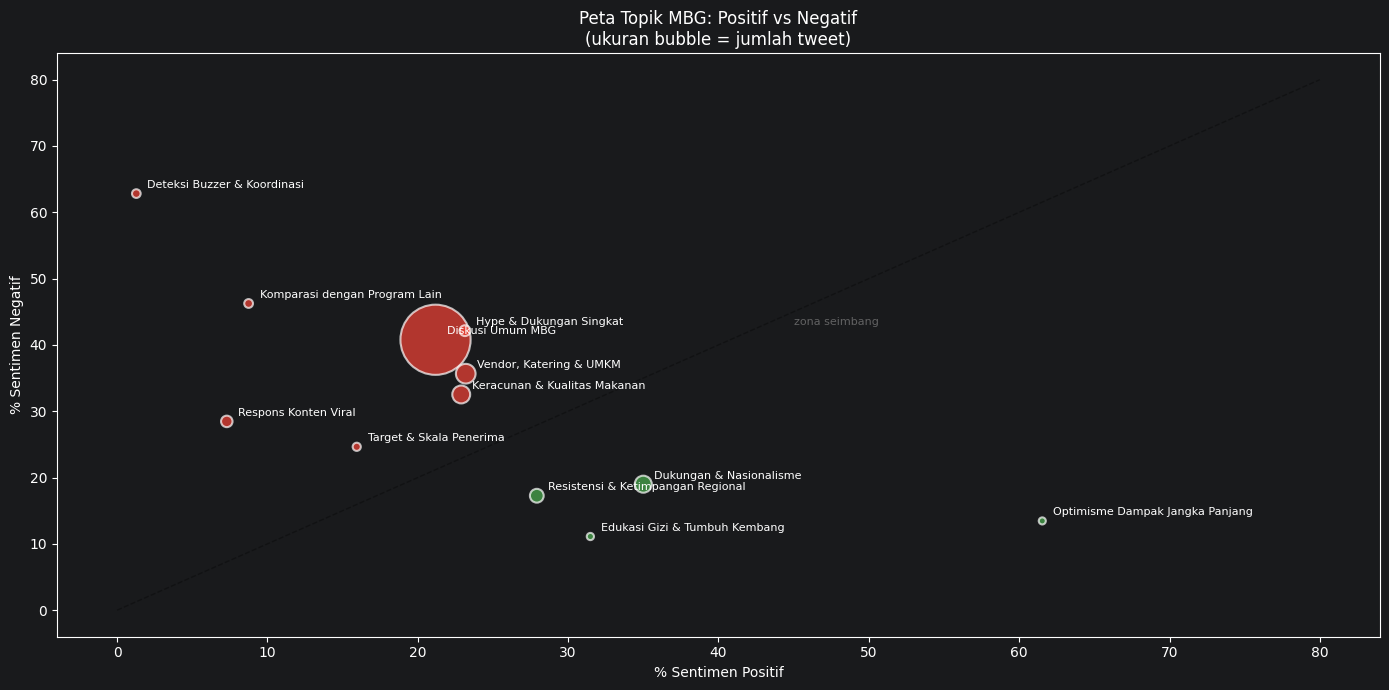

In [6]:
# Rename topik jadi lebih presentable
topic_rename = {
    'generasi_enggak_ekonomi'       : 'Diskusi Umum MBG',
    'cegah_indonesia emas_gizi anak': 'Dukungan & Nasionalisme',
    'menu_basi_susu'                : 'Keracunan & Kualitas Makanan',
    'buzzer_bayar_tweet'            : 'Deteksi Buzzer & Koordinasi',
    'food_vendor_produk'            : 'Vendor, Katering & UMKM',
    'papua_anakanak_tolak'          : 'Resistensi & Ketimpangan Regional',
    'viral_konten_klarifikasi'      : 'Respons Konten Viral',
    'banding_daerah_lebih baik'     : 'Komparasi dengan Program Lain',
    'nutrisi_tumbuh_anakanak'       : 'Edukasi Gizi & Tumbuh Kembang',
    'optimal_tumbuh_tumbuh kembang' : 'Optimisme Dampak Jangka Panjang',
    'gas_gasnow_oke'                : 'Hype & Dukungan Singkat',
    'target_juta_juta terima'       : 'Target & Skala Penerima',
}

df['topic_readable'] = df['topic_label'].map(topic_rename).fillna('Outlier')

# Visualisasi final — bubble chart ukuran = jumlah tweet, warna = sentimen dominan
topic_summary = df[df['topic_id'] != -1].groupby('topic_readable').agg(
    jumlah=('topic_readable', 'count'),
    pct_positif=('sentiment_bert', lambda x: (x == 'positif').mean() * 100),
    pct_negatif=('sentiment_bert', lambda x: (x == 'negatif').mean() * 100),
).reset_index()

topic_summary['dominant_sentiment'] = topic_summary.apply(
    lambda r: 'positif' if r['pct_positif'] > r['pct_negatif'] else 'negatif', axis=1
)

colors = topic_summary['dominant_sentiment'].map({'positif': '#4CAF50', 'negatif': '#F44336'})

fig, ax = plt.subplots(figsize=(14, 7))
scatter = ax.scatter(
    topic_summary['pct_positif'],
    topic_summary['pct_negatif'],
    s=topic_summary['jumlah'] * 0.5,
    c=colors,
    alpha=0.7,
    edgecolors='white',
    linewidths=1.5
)

for _, row in topic_summary.iterrows():
    ax.annotate(
        row['topic_readable'],
        (row['pct_positif'], row['pct_negatif']),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=8
    )

# Garis diagonal = zona seimbang
lims = [0, 80]
ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=1)
ax.text(45, 43, 'zona seimbang', fontsize=8, color='gray', alpha=0.7)

ax.set_xlabel('% Sentimen Positif')
ax.set_ylabel('% Sentimen Negatif')
ax.set_title('Peta Topik MBG: Positif vs Negatif\n(ukuran bubble = jumlah tweet)')
plt.tight_layout()
plt.show()